In [ ]:
# Ensure the notebook uses the repository root as its working directory whether launched from notebooks/ or the repository root
import os, sys
from pathlib import Path
ROOT = Path.cwd()
ROOT = ROOT.parent if ROOT.name == "notebooks" else ROOT
os.chdir(ROOT)
sys.path.insert(0, str(ROOT))


# P2C Net

The main task is to train, for each topology, a regression model that maps performance metrics to circuit parameters.
There are two kinds of data—performance metrics and circuit parameters (both one-dimensional vectors). The true mapping from circuit parameters to performance metrics is known through the existing simulator. The goal is to train the inverse regression model: given performance metrics, predict the circuit parameters needed to realize them. Training data include existing performance–parameter pairs and may also include performance targets not present in the database; after predicting parameters for those targets, simulate them to obtain the true metrics. In principle, three losses can be constructed:
* For existing pairs, the loss between predicted and true circuit parameters (fast convergence).
* For existing pairs, the loss between the simulated metrics of the predicted parameters and the input metrics (robustness; reflects actual performance).
* For targets not in existing pairs, the loss between the simulated metrics of the predicted parameters and the input metrics (generalization).

## Imports and Interface

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import csv
import os
import time
import pandas as pd

# Private packages
from paradigm.netlist_utils import CircuitParams, FitnessFunction_Prallel_Tailor, make_fitness_function
from paradigm.turbo import TurboM_Plus

In [2]:
# Interface
# Use CSMC018
technique_path = './circuits/design_space.json'
scs_mdl_path = './circuits'
run_path = './runs'
database_path = './circuit_database'

# Circuit name provided by the user for Benchmark evaluation
# ckt_name = input('\033[32mPlease input the circuit name: [ckt_name]\n')
# SMC/NMCNR/DFCFC1/NGCC/TCFC/AZC/IAC
ckt_name = 'SMC'

# Check if there is a directory of scs and mdl files for the circuit
if not os.path.exists(scs_mdl_path+'/'+ckt_name):
    print(f'\033[31mPlease add netlist and testbench files (in the format of scs and mdl) for the circuit [{ckt_name}] before running the Benchmark\033[0m')
    
scs_mdl_paths = [
    {'scs': scs_mdl_path+'/'+ckt_name+f'/{ckt_name}_da.scs', 'mdl': scs_mdl_path+'/'+ckt_name+f'/{ckt_name}_da.mdl', 'name': 'da'},
    {'scs': scs_mdl_path+'/'+ckt_name+f'/{ckt_name}_tran.scs', 'mdl': scs_mdl_path+'/'+ckt_name+f'/{ckt_name}_tran.mdl', 'name': 'tran'},
    ]

ckt_database_path = database_path + '/' + ckt_name
P2C_model_save_path = ckt_database_path + '/P2C_model'

In [3]:
# Read database parameters
csv_path = ckt_database_path + '/' + 'result.csv'
# csv read
ckt_database_csv = pd.read_csv(csv_path)
# Strip whitespace from column names
ckt_database_csv.columns = ckt_database_csv.columns.str.strip()

# info head groupby
print(ckt_database_csv.info())
print("--"*20)

print(ckt_database_csv.head())
print("--"*20)

print(ckt_database_csv.groupby('performance weight').size())    

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 378 entries, 0 to 377
Data columns (total 8 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   GBW                 378 non-null    float64
 1   Gain                378 non-null    float64
 2   Pdiss               378 non-null    float64
 3   Fitness             378 non-null    object 
 4   time                378 non-null    object 
 5   performance weight  378 non-null    object 
 6   solution vector     378 non-null    object 
 7   solution path       378 non-null    object 
dtypes: float64(3), object(5)
memory usage: 23.8+ KB
None
----------------------------------------
          GBW     Gain     Pdiss             Fitness              time  \
0   2785900.0  34.4130  0.000983   -9.45231305243248  2025-0521-121547   
1   7595330.0  85.2316  0.001155  -9.818148948736107  2025-0521-121556   
2   1479350.0  77.8502  0.000907  -9.212365022199068  2025-0521-121605   
3   4401590

### Database data

The main data are $ ​(P_{actual\_db}, C_{actual\_db}) $

In [4]:
# abstract training data from csv file
GBW_column = ckt_database_csv['GBW']    # Hz, float64
Gain_column = ckt_database_csv['Gain']  # dB, float64
Pdiss_column = ckt_database_csv['Pdiss']  # W, float64
Solution_vector_column = ckt_database_csv['solution vector']  # str, object
# str to array
# print(Solution_vector_column.head())
Solution_vector_column = np.vstack(Solution_vector_column.apply(lambda x: np.fromstring(x.strip('[]'), sep=' ')))

# contactate into a 3-dim array
# P for Performance Metrix, C for Circuit Parameters, db for Database, gen for Generated Data, M for Model, S for Simulator
P_actual_db = np.array([GBW_column, Gain_column, Pdiss_column]).T
C_actual_db = np.array(Solution_vector_column)

# print("P_actual_db shape: ", P_actual_db.shape)
# print("C_actual_db shape: ", C_actual_db.shape)

# print(P_actual_db[0:5])
# print(C_actual_db[0:5])

dims_Perf = P_actual_db.shape[1]
dims_Circ = C_actual_db.shape[1]
print("dims_Perf: ", dims_Perf)
print("dims_Circ: ", dims_Circ)

dims_Perf:  3
dims_Circ:  11


### Generated data

This is primarily $ P_{actual\_gen} $, used to improve generalization.

In [5]:
def generate_P_actual_gen(p_actual_db_batch, strategy="perturb", scale=1):
    """
    Generate new performance metrics based on the existing ones in the database.
    Args:
        p_actual_db_batch (torch.Tensor): Performance metrics from the database.
        strategy (str): Strategy for generating new performance metrics. Options are "perturb" or "interpolate".
        scale (float): Scale for perturbation.
    Returns:
        torch.Tensor: Generated performance metrics with the same shape as p_actual_db_batch.
    """
    if strategy == "perturb":
        # Generate random noise with the same shape as p_actual_db_batch, sampled from a standard normal distribution
        noise = torch.randn_like(p_actual_db_batch) * scale
        # Scale the noise to [-1, 1] with a sigmoid function; when noise is 0, sigmoid(noise) is 1
        noise = 2 * torch.sigmoid(noise) - 1
        # This keeps the perturbation within 0–2 times the original data
        p_actual_gen = p_actual_db_batch * (1 + noise)
    elif strategy == "interpolate" and p_actual_db_batch.size(0) > 1:
        # Randomly generate two distinct index arrays by permuting 0, 1, ..., n-1
        idx1 = torch.randperm(p_actual_db_batch.size(0))
        idx2 = torch.randperm(p_actual_db_batch.size(0))
        # Generate a random sequence alpha uniformly in [0, 1] with shape (batch_size, 1)
        alpha = torch.rand(p_actual_db_batch.size(0), 1, device=p_actual_db_batch.device)
        # Randomly pair samples and linearly interpolate them with coefficient alpha
        p_actual_gen = alpha * p_actual_db_batch[idx1] + (1 - alpha) * p_actual_db_batch[idx2]
    else: # Default strategy
        noise = torch.randn_like(p_actual_db_batch) * scale
        noise = 2 * torch.sigmoid(noise) - 1
        p_actual_gen = p_actual_db_batch * (1 + noise)
    return p_actual_gen

## P2C Net

### Scaler

Data/target scale imbalance is a common and important factor affecting neural-network training and convergence. Addressing it usually requires preprocessing and possibly loss-function adjustments.

**1. Input/output preprocessing (normalization/standardization)**

The core idea is to scale all input features (performance metrics $P$) and output targets (circuit parameters $C$) to comparable numeric ranges—typically mean 0 and standard deviation 1 (standardization), or a range of [0, 1] or [-1, 1] (normalization).

* **Why preprocess?**
    * **Faster convergence**: When feature ranges differ greatly, loss gradients differ by direction, causing the optimizer to take a winding path and converge slowly.
    * **Avoid numerical problems**: Extremely large or small values can overflow or lose precision.
    * **Fairer weighting**: The network will not over-focus on numerically large features while ignoring small ones.

* **Procedure:**

    a.  **Choose a scaler (Scaler):**
        * `StandardScaler`: $x' = (x - \mu) / \sigma$. Suitable for approximately Gaussian data or settings less sensitive to outliers.
        * `MinMaxScaler`: $x' = (x - \min) / (\max - \min)$. Scales data to [0, 1] and is sensitive to outliers.
        * `RobustScaler`: Scales using the median and interquartile range and is more robust to outliers.
        * **Log transform (Log Transform)**: For highly skewed data or values spanning several orders of magnitude (for example, frequency in Hz or power in W), apply a log transform (such as $log_{10}(x)$ or $ln(x)$) before standardization/normalization. This can be useful for GBW (Hz, on the order of M) and Pdiss (W, on the order of m). Gain (dB) is already approximately logarithmic, so an additional log transform may not be needed; standardization/normalization is sufficient. Circuit parameters such as lengths (micrometers) and resistances (kΩ) may also benefit from a log transform when their ranges are very broad.

    b.  **Compute scaling parameters:**
        * **Use only the training data (training set)** to compute parameters such as $mu, \sigma, \min, \max$. This is essential to avoid data leakage.
        * Maintain separate scalers/scaling parameters for performance metrics $P$ and circuit parameters $C$.

    c.  **Apply scaling:**
        * **P2P-Net input ($P_{actual\_db}, P_{actual\_gen}$)**: Transform with the performance-metric scaler.
        * **P2P-Net target output ($C_{actual\_db}$)**: Transform with the circuit-parameter scaler. The network learns to predict these *scaled* circuit parameters.
        * **$C_{pred}$ passed to simulator $S$**: The network outputs scaled $C'_{pred}$. **Before** passing it to $S$, use the circuit-parameter scaler's `inverse_transform` method to **restore it to the original physical scale** $C_{pred}$. The simulator always operates on physical-scale values.
        * **Simulator $S$ output $P_{pred}$**: The simulator output is on the physical scale. **Before** computing $L_2$ and $L_3$ losses (if they expect scaled values), use the performance-metric scaler to **convert it to the scaled space** $P'_{pred}$.

    d.  **Inference/prediction:**
        * Transform new input metrics $P_{new}$ with the performance-metric scaler fitted during training.
        * Apply the circuit-parameter scaler's `inverse_transform` to the network's scaled output $C'_{pred}$ to restore physical scale; this is the final usable result.

In [6]:
# In short, compute all scaler parameters directly from the training data
# Then place fixed mapping layers (with no trainable parameters) directly at the network input and output

# Alternatively, normalize the training data first (both inputs and outputs),
# train the neural network, and inverse-transform its predictions afterward; the mapping layers do not participate in network training

# The information flow is similar in both approaches. The main difference may be loss computation: without relative error, the first approach remains unbalanced, whereas the second does not, but the second is less convenient when cascading models that require raw inputs
# The first approach also lets you save scaler parameters with the model for plug-and-play reuse; the second requires saving a separate scaler model

# Use the first approach!

1. Modify the P2PNet class: store Scaler parameters as model buffers (non-trainable parameters saved and loaded with model state), and implement input normalization and output inverse transformation in `forward`.
2. Implement `RelativeMSELoss`: create a custom PyTorch loss that computes relative mean-squared error on the physical scale.
3. Modify the training loop: update the training function to handle physical-scale inputs and outputs and use `RelativeMSELoss`.

See the code below for the implementation.

### Network Definition

In [7]:
# P2C-Net (Performance_Metrix-to-Circuit_Parameters Network)

class InputScaler_P(nn.Module):
    """
    Normalization preprocessing for neural-network inputs
        The input is P (performance metrics), such as `Gain`, GBW, and `Pdiss`, whose scales are relatively large
        Normalize with the mean and standard deviation, and use epsilon to prevent division by zero
    """
    def __init__(self, p_mean, p_scale, epsilon=1e-8):
        super(InputScaler_P, self).__init__()
        self.register_buffer('p_mean', torch.tensor(p_mean, dtype=torch.float32))
        self.register_buffer('p_scale', torch.tensor(p_scale, dtype=torch.float32))
        self.epsilon = epsilon

    def forward(self, x):
        return (x - self.p_mean) / (self.p_scale + self.epsilon)


class FromUnicube_C(nn.Module):
    """
    Processing for neural-network outputs
        The output is C (circuit parameters) in [lb, ub], whose scales can differ greatly (for example, transistor sizes and resistor values)
        Use a linear mapping to avoid division-by-zero errors and the difficulty of choosing an epsilon scale
    """
    def __init__(self, lb, ub):
        super(FromUnicube_C, self).__init__()
        self.register_buffer('lb', torch.tensor(lb, dtype=torch.float32))
        self.register_buffer('ub', torch.tensor(ub, dtype=torch.float32))

    def forward(self, x):
        return x * (self.ub - self.lb) + self.lb


class P2C_Net(nn.Module):
    def __init__(self, dim_perfs, dim_params, p_mean, p_scale, lb, ub):
        super(P2C_Net, self).__init__()
        self.dim_perfs = dim_perfs
        self.dim_params = dim_params

        # Normalize the input
        self.input_scaler = InputScaler_P(p_mean, p_scale)

        # Core network: 256-512-256
        self.core_network = nn.Sequential(
            nn.Linear(dim_perfs, 256),
            nn.ReLU(),
            nn.Dropout(0.2),
            
            nn.Linear(256, 512),
            nn.ReLU(),
            nn.Dropout(0.2),
            
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Dropout(0.2),
            
            nn.Linear(256, dim_params),
            nn.Sigmoid(),              # Constrain to [0,1]
            FromUnicube_C(lb, ub)        # Map to [lb, ub]
        )

    def forward(self, p_actual_physical):
        if p_actual_physical.ndim == 1:
            p_actual_physical = p_actual_physical.unsqueeze(0)
        # Normalize the input
        p_scaled = self.input_scaler(p_actual_physical)
        # Run the forward pass through the core network and map the output to [lb, ub]
        return self.core_network(p_scaled)


## Simulator Interface

In [8]:
from paradigm.netlist_utils import C2P_Simulator

circuit = CircuitParams(scs_mdl_paths[0]["scs"], technique_path)
C2P_Sim = C2P_Simulator(scs_mdl_paths, run_path, ckt_name, circuit.params, circuit.wsub, database_path, [])
# C2P_Sim accepts a PyTorch tensor (batch_size, dim_params) as input and returns a PyTorch tensor (batch_size, target_perf_dim)

In [9]:
# Quick test of C2P_Sim
print("input Circuit Parameters: ", C_actual_db[5:8])
print("C2P output: ", C2P_Sim(C_actual_db[5:8]))
print("expect output: ", P_actual_db[5:8])

input Circuit Parameters:  [[1.84962283e-04 5.65518798e-07 7.01741404e-05 1.10239463e-06
  1.71977930e-06 1.24014045e-06 5.67857278e-04 5.77899632e-07
  1.02862731e-04 1.93444707e-06 2.57376957e-12]
 [1.36184065e-04 5.13679454e-07 1.09468792e-05 9.79355939e-07
  2.33640364e-06 1.08284533e-06 5.95047918e-04 5.28519769e-07
  1.29044595e-04 1.89803467e-06 2.18936585e-12]
 [1.63326258e-04 5.49869199e-07 6.41840706e-06 1.06010308e-06
  8.75281189e-06 1.12579388e-06 6.21221390e-04 6.14328053e-07
  1.21397801e-04 1.91297590e-06 2.23469100e-12]]
C2P output:  tensor([[3.1625e+06, 9.0121e+01, 1.5089e-03],
        [4.5845e+06, 9.0122e+01, 1.1923e-03],
        [1.0724e+07, 8.8912e+01, 1.3920e-03]])
expect output:  [[3.16247e+06 9.01206e+01 1.50890e-03]
 [4.58447e+06 9.01221e+01 1.19230e-03]
 [1.07240e+07 8.89123e+01 1.39204e-03]]


In [10]:
# Use a custom autograd.Function to implement finite differences
# Set perturbations according to the parameter scale (the range between lb and ub)
class SimulateWithFiniteDifference(torch.autograd.Function):
    @staticmethod
    def forward(ctx,                    # ctx is the context object used to save information for backward
                c_pred_batch,           # Input parameter tensor (N, dim_params)
                black_box_sim_fn,       # Actual black-box simulation function
                epsilon_fd,             # Finite-difference perturbation, possibly a vector (dim_params,)
                target_perf_dim_k):     # Simulator output performance dimension (k)

        # Convert to a Tensor (ensuring float32)
        if not isinstance(epsilon_fd, torch.Tensor):
            epsilon_fd = torch.tensor(epsilon_fd, dtype=c_pred_batch.dtype, device=c_pred_batch.device)
        else:
            epsilon_fd = epsilon_fd.to(dtype=c_pred_batch.dtype, device=c_pred_batch.device)

        # Save the context for backward
        ctx.black_box_sim_fn = black_box_sim_fn
        ctx.epsilon_fd = epsilon_fd
        ctx.target_perf_dim_k = target_perf_dim_k
        # Save a copy of c_pred_batch to compute the Jacobian in backward
        # detach() ensures that this path does not accidentally create edges in the PyTorch computation graph
        ctx.save_for_backward(c_pred_batch.detach().clone())

        # Call the black-box simulator
        # Run the forward simulation (without building gradients)
        p_actual_sim_batch = black_box_sim_fn(c_pred_batch.detach().clone(), target_perf_dim_k)
        return p_actual_sim_batch
    
    @staticmethod
    def backward(ctx, grad_output):                 # grad_output: (N, k), i.e. dL/dS(C_pred)
        
        c_pred_batch_original, = ctx.saved_tensors  # (N, m)
        black_box_sim_fn = ctx.black_box_sim_fn
        epsilon_fd = ctx.epsilon_fd                 # (m,)
        
        k = ctx.target_perf_dim_k           # k is the simulator output performance dimension
        N, m = c_pred_batch_original.shape  # N is the batch size and m is the circuit-parameter dimension

        assert epsilon_fd.shape[0] == m, "epsilon_fd shape mismatch"

        # Construct 2*N*m perturbed samples
        # For sample i and dimension j, create two perturbed samples (plus eps and minus eps)
        # Result shape: (2 * N * m, m)
        perturb_inputs = []
        for i in range(N):
            for j in range(m):
                c_orig = c_pred_batch_original[i]
                eps = epsilon_fd[j]

                c_plus = c_orig.clone()
                c_plus[j] += eps
                c_minus = c_orig.clone()
                c_minus[j] -= eps

                perturb_inputs.extend([c_plus, c_minus])
        
        perturb_inputs = torch.stack(perturb_inputs, dim=0)  # shape: (2*N*m, m)

        # Batch simulation
        with torch.no_grad():  # Do not build a computation graph
            # Run simulations in parallel for speed
            perturb_outputs = black_box_sim_fn(perturb_inputs, k)  # (2*N*m, k)
            # Move device to the one used by c_pred_batch_original
            perturb_outputs = perturb_outputs.to(c_pred_batch_original.device)

        # Construct the Jacobian matrix
        grad_c_pred_batch = torch.zeros_like(c_pred_batch_original)

        for i in range(N):
            jacobian_i = torch.zeros((k, m), device=c_pred_batch_original.device)
            for j in range(m):
                idx = 2 * (i * m + j)
                p_plus = perturb_outputs[idx]     # (k,)
                p_minus = perturb_outputs[idx+1]  # (k,)
                eps = epsilon_fd[j]

                jacobian_i[:, j] = (p_plus - p_minus) / (2 * eps)

            # Move grad_output to the target device
            grad_output = grad_output.to(c_pred_batch_original.device)
            grad_c_pred_batch[i] = grad_output[i].unsqueeze(0) @ jacobian_i  # (1, k) @ (k, m)

        return grad_c_pred_batch, None, None, None


## Training Loop

In [11]:
# Use different loss definitions for performance and parameter losses
# class RelativeMSELoss(nn.Module):
#     def __init__(self, eps=1e-8):
#         super().__init__()
#         self.eps = eps
#     def forward(self, pred, target):
#         relative_error = (pred - target) / (target + self.eps)
#         return torch.mean(relative_error ** 2)
# criterion_mrse = RelativeMSELoss(eps=1e-8) # Because some circuit parameters can be very small (1e-12), leave eps unset for now
class MRSE_Loss_C(nn.Module):
    """
    Mean-squared-error loss for circuit parameters
        Circuit-parameter dimensions differ greatly, so use ToUnicube for a linear mapping
        Then compute the relative error
    """
    def __init__(self, c_lb, c_ub, eps=1e-8):
        super(MRSE_Loss_C, self).__init__()
        # Remember to convert to torch.tensor
        # self.c_lb = torch.tensor(c_lb, dtype=torch.float32)
        # self.c_ub = torch.tensor(c_ub, dtype=torch.float32)
        self.eps = eps
    def forward(self, pred, target):
        # # Linearly map to [0, 1]
        # pred_unicube = (pred - self.c_lb) / (self.c_ub - self.c_lb)
        # target_unicube = (target - self.c_lb) / (self.c_ub - self.c_lb)
        
        # NOTE: The mapping seems unhelpful, so omit it
        pred_unicube = pred
        target_unicube = target
        
        # Compute the relative error
        relative_error = (pred_unicube - target_unicube) / (target_unicube + self.eps)
        return torch.mean(relative_error ** 2)

class MRSE_Loss_P(nn.Module):
    """
    Mean-squared-error loss for circuit metrics
        Circuit metrics are large in scale, so compute the relative error directly
    """
    def __init__(self, eps=1e-8):
        super(MRSE_Loss_P, self).__init__()
        self.eps = eps
    def forward(self, pred, target):
        # Compute the relative error
        # Ensure all tensors are on the same device
        if pred.device != target.device:
            pred = pred.to(target.device)
        
        relative_error = (pred - target) / (target + self.eps)
        return torch.mean(relative_error ** 2)

def train_p2c_net_with_fd(model,
                          dataloader_db,
                          Loss_P,
                          Loss_C,
                          num_epochs,
                          learning_rate,
                          lambda1_schedule, # for L2
                          lambda2_schedule, # for L3
                          device,
                          dim_perfs_k_val=None,    # Actual simulator output performance dimension (k)
                          fd_epsilon_val=1e-8 * np.ones(dims_Circ), # Finite-difference perturbation (m,)
):
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)
    
    history = {'epoch': [], 'total_loss': [], 'l1_param': [], 'l2_perf_db': [], 'l3_perf_gen': [], 'sim_calls_per_epoch': []}
    
    print(f"Starting training with finite differences. FD Epsilon: {fd_epsilon_val}")

    for epoch in range(num_epochs):
        model.train()
        
        lambda1 = lambda1_schedule(epoch)
        lambda2 = lambda2_schedule(epoch)

        epoch_total_loss = 0.0
        epoch_l1 = 0.0
        epoch_l2 = 0.0
        epoch_l3 = 0.0
        epoch_sim_calls = 0
        num_batches = 0

        for batch_idx, (p_actual_db_batch, c_actual_db_batch) in enumerate(dataloader_db):
            p_actual_db_batch = p_actual_db_batch.to(device)
            c_actual_db_batch = c_actual_db_batch.to(device)
            
            current_batch_size = p_actual_db_batch.shape[0]
            # model.dim_params is the dimension of the model output (C_pred)
            sim_calls_this_batch_fd_part = current_batch_size * model.dim_params * 2 
            sim_calls_this_batch_fw_part = 0


            optimizer.zero_grad()

            c_pred_db_batch = model(p_actual_db_batch)
            
            # --- Loss 1 (L1_param) ---
            c_pred_db_for_l1 = c_pred_db_batch
            l1_param = Loss_C(c_pred_db_for_l1, c_actual_db_batch)
            total_loss = l1_param
            
            current_l2_perf_db_val = torch.tensor(0.0, device=device)
            current_l3_perf_gen_val = torch.tensor(0.0, device=device)

            # --- Loss 2 (L2_perf_db) ---
            if lambda1 > 0:
                c_pred_db_for_l2 = c_pred_db_batch
                # Use the custom autograd Function for simulation
                p_pred_db = SimulateWithFiniteDifference.apply(
                    c_pred_db_for_l2, 
                    C2P_Sim, # Pass the actual black-box simulation function
                    fd_epsilon_val,
                    dim_perfs_k_val # Simulator output dimension k
                )
                sim_calls_this_batch_fw_part += current_batch_size # FD forward pass simulation
                epoch_sim_calls += sim_calls_this_batch_fd_part + current_batch_size # Jacobian sims + forward pass sims

                current_l2_perf_db_val = Loss_P(p_pred_db, p_actual_db_batch)
                total_loss = total_loss + lambda1 * current_l2_perf_db_val # Ensure it is added to total_loss
            
            # --- Loss 3 (L3_perf_gen) ---
            # Data are generated within each epoch, while the training inputs remain fixed and are supplied by dataloader_db
            if lambda2 > 0:
                p_actual_gen_batch = generate_P_actual_gen(p_actual_db_batch, "interpolate").to(device)
                c_pred_gen = model(p_actual_gen_batch)
                p_pred_gen = SimulateWithFiniteDifference.apply(
                    c_pred_gen,
                    C2P_Sim,
                    fd_epsilon_val,
                    dim_perfs_k_val
                )
                sim_calls_this_batch_fw_part += current_batch_size # FD forward pass simulation
                epoch_sim_calls += sim_calls_this_batch_fd_part + current_batch_size # Jacobian sims + forward pass sims

                current_l3_perf_gen_val = Loss_P(p_pred_gen, p_actual_gen_batch)
                total_loss = total_loss + lambda2 * current_l3_perf_gen_val

            # --- Backward pass and optimization ---
            total_loss.backward()
            optimizer.step()

            epoch_total_loss += total_loss.item()
            epoch_l1 += l1_param.item()
            if lambda1 > 0: epoch_l2 += current_l2_perf_db_val.item()
            if lambda2 > 0: epoch_l3 += current_l3_perf_gen_val.item()
            num_batches += 1
            
            # if batch_idx % 1 == 0: # Reduce print frequency because finite differences are slow
            #      print(f"  Epoch {epoch+1}, Batch [{batch_idx+1}/{len(dataloader_db)}], Size {current_batch_size}, TotalLoss: {total_loss.item():.4f}, "
            #            f"L1: {l1_param.item():.4f}, L2: {current_l2_perf_db_val.item():.4f}, L3: {current_l3_perf_gen_val.item():.4f}")

        avg_total_loss = epoch_total_loss / num_batches
        avg_l1 = epoch_l1 / num_batches
        avg_l2 = epoch_l2 / num_batches if lambda1 > 0 and num_batches > 0 else 0
        avg_l3 = epoch_l3 / num_batches if lambda2 > 0 and num_batches > 0 else 0
        
        history['epoch'].append(epoch)
        history['total_loss'].append(avg_total_loss)
        history['l1_param'].append(avg_l1)
        history['l2_perf_db'].append(avg_l2)
        history['l3_perf_gen'].append(avg_l3)
        history['sim_calls_per_epoch'].append(epoch_sim_calls)

        print(f"Epoch [{epoch+1}/{num_epochs}], "
              f"Avg Total Loss: {avg_total_loss:.4f}, "
              f"Avg L1: {avg_l1:.4f}, "
              f"Avg L2: {avg_l2:.4f} (λ1={lambda1:.2f}), "
              f"Avg L3: {avg_l3:.4f} (λ2={lambda2:.2f}), "
              f"Sim Calls this Epoch: {epoch_sim_calls}")
        
        # Add early stopping; late-training loss may fluctuate locally while decreasing overall
        # Use L1 loss as the early-stopping criterion
        # Early stopping affects the settings of loss2 and loss3; ignore that for now
        
              
    return history

## Main Loop

In [12]:
# Configuration
from sklearn.discriminant_analysis import StandardScaler

DIM_PERFS_K = dims_Perf
DIM_PARAMS_M = dims_Circ

MAX_DATA_SIZE = 9999    # Maximum dataset size allowed for training

NUM_EPOCHS = 20000        # Number of epochs
LEARNING_RATE = 1e-5    # Learning rate
BATCH_SIZE = 10         # Ten samples per batch

c_lb = np.array(circuit.lb)
c_ub = np.array(circuit.ub)
FD_EPSILON = 1e-4 * (c_ub - c_lb)  # Finite-difference perturbation, scaled to the parameters

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Load training data

# If the dataset exceeds the limit, randomly select MAX_DATA_SIZE samples
if len(P_actual_db) > MAX_DATA_SIZE:
    # Randomly select MAX_DATA_SIZE samples
    indices = np.random.choice(len(P_actual_db), MAX_DATA_SIZE, replace=False)
    P_actual_db = P_actual_db[indices]
    C_actual_db = C_actual_db[indices]
else:
    pass

P_actual_db_tensor = torch.tensor(P_actual_db, dtype=torch.float32, device=device)
C_actual_db_tensor = torch.tensor(C_actual_db, dtype=torch.float32, device=device)
dataset_db = torch.utils.data.TensorDataset(P_actual_db_tensor, C_actual_db_tensor)
dataloader_db = torch.utils.data.DataLoader(dataset_db, batch_size=BATCH_SIZE, shuffle=True)

# Compute scaling parameters
p_scaler = StandardScaler()
p_scaler.fit(P_actual_db)
p_mean_np, p_scale_np = p_scaler.mean_, p_scaler.scale_
print("P_mean: ", p_mean_np)
print("P_scale: ", p_scale_np)

# Get lb and ub
c_lb = np.array(circuit.lb)
c_ub = np.array(circuit.ub)
print("C_lb: ", c_lb)
print("C_ub: ", c_ub)

# Lambda scheduler
def lambda1_scheduler_fn(epoch): # L2 weight
    if epoch < NUM_EPOCHS: return 0.0 # Disable L2 initially
    else: return 0.5          # Enable L2 later

def lambda2_scheduler_fn(epoch): # L3 weight
    if epoch < NUM_EPOCHS: return 0.0 # Enable L3 even later
    else: return 0.3

# Create the model
p2c_model_fd = P2C_Net(dim_perfs=DIM_PERFS_K, dim_params=DIM_PARAMS_M, p_mean=p_mean_np, p_scale=p_scale_np, lb=c_lb, ub=c_ub).to(device)
print(p2c_model_fd)

Using device: cuda
P_mean:  [2.44261308e+07 9.15400058e+01 2.37435545e-03]
P_scale:  [3.09891136e+07 1.15609374e+01 2.33899682e-03]
C_lb:  [2.e-07 5.e-07 2.e-07 5.e-07 2.e-07 5.e-07 2.e-07 5.e-07 2.e-07 5.e-07
 5.e-13]
C_ub:  [1.e-03 2.e-06 1.e-03 2.e-06 1.e-03 2.e-06 1.e-03 2.e-06 1.e-03 2.e-06
 3.e-12]
P2C_Net(
  (input_scaler): InputScaler_P()
  (core_network): Sequential(
    (0): Linear(in_features=3, out_features=256, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_features=256, out_features=512, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.2, inplace=False)
    (6): Linear(in_features=512, out_features=256, bias=True)
    (7): ReLU()
    (8): Dropout(p=0.2, inplace=False)
    (9): Linear(in_features=256, out_features=11, bias=True)
    (10): Sigmoid()
    (11): FromUnicube_C()
  )
)


In [13]:
# Train and save
Loss_C = MRSE_Loss_C(c_lb, c_ub, eps=1e-8).to(device)
Loss_P = MRSE_Loss_P(eps=1e-8).to(device)

print(f"\nStarting finite-difference (FD) training for {NUM_EPOCHS} epochs...")
training_history_fd = train_p2c_net_with_fd(
    p2c_model_fd,
    dataloader_db,
    Loss_P,
    Loss_C,
    NUM_EPOCHS,
    LEARNING_RATE,
    lambda1_scheduler_fn,
    lambda2_scheduler_fn,
    device,
    dim_perfs_k_val=DIM_PERFS_K, # This is the output dimension k of S
    fd_epsilon_val=FD_EPSILON
)

print("\nFD training complete.")

# Add a timestamp and save the model
timestamp = time.strftime("%Y%m%d-%H%M%S")
model_save_path = P2C_model_save_path + f"/P2C_Net_FD_{ckt_name}_{timestamp}.pt"
if not os.path.exists(P2C_model_save_path):
    os.makedirs(P2C_model_save_path)
torch.save(p2c_model_fd.state_dict(), model_save_path)
print(f"Model saved to: {model_save_path}")
# Save the training history
history_save_path = P2C_model_save_path + f"/P2C_Net_FD_{ckt_name}_{timestamp}_history.csv"
with open(history_save_path, 'w', newline='') as csvfile:
    fieldnames = ['epoch', 'total_loss', 'l1_param', 'l2_perf_db', 'l3_perf_gen', 'sim_calls_per_epoch']
    writer = csv.DictWriter(csvfile, fieldnames=fieldnames)
    writer.writeheader()
    for i in range(len(training_history_fd['epoch'])):
        writer.writerow({
            'epoch': training_history_fd['epoch'][i],
            'total_loss': training_history_fd['total_loss'][i],
            'l1_param': training_history_fd['l1_param'][i],
            'l2_perf_db': training_history_fd['l2_perf_db'][i],
            'l3_perf_gen': training_history_fd['l3_perf_gen'][i],
            'sim_calls_per_epoch': training_history_fd['sim_calls_per_epoch'][i]
        })
print(f"Training history saved to: {history_save_path}")


Starting finite-difference (FD) training for 20000 epochs...
Starting training with finite differences. FD Epsilon: [9.998e-08 1.500e-10 9.998e-08 1.500e-10 9.998e-08 1.500e-10 9.998e-08
 1.500e-10 9.998e-08 1.500e-10 2.500e-16]
Epoch [1/20000], Avg Total Loss: 6326.8159, Avg L1: 6326.8159, Avg L2: 0.0000 (λ1=0.00), Avg L3: 0.0000 (λ2=0.00), Sim Calls this Epoch: 0
Epoch [2/20000], Avg Total Loss: 6338.9301, Avg L1: 6338.9301, Avg L2: 0.0000 (λ1=0.00), Avg L3: 0.0000 (λ2=0.00), Sim Calls this Epoch: 0
Epoch [3/20000], Avg Total Loss: 6052.4859, Avg L1: 6052.4859, Avg L2: 0.0000 (λ1=0.00), Avg L3: 0.0000 (λ2=0.00), Sim Calls this Epoch: 0
Epoch [4/20000], Avg Total Loss: 5927.1304, Avg L1: 5927.1304, Avg L2: 0.0000 (λ1=0.00), Avg L3: 0.0000 (λ2=0.00), Sim Calls this Epoch: 0
Epoch [5/20000], Avg Total Loss: 5686.3738, Avg L1: 5686.3738, Avg L2: 0.0000 (λ1=0.00), Avg L3: 0.0000 (λ2=0.00), Sim Calls this Epoch: 0
Epoch [6/20000], Avg Total Loss: 5860.7436, Avg L1: 5860.7436, Avg L2: 0.00

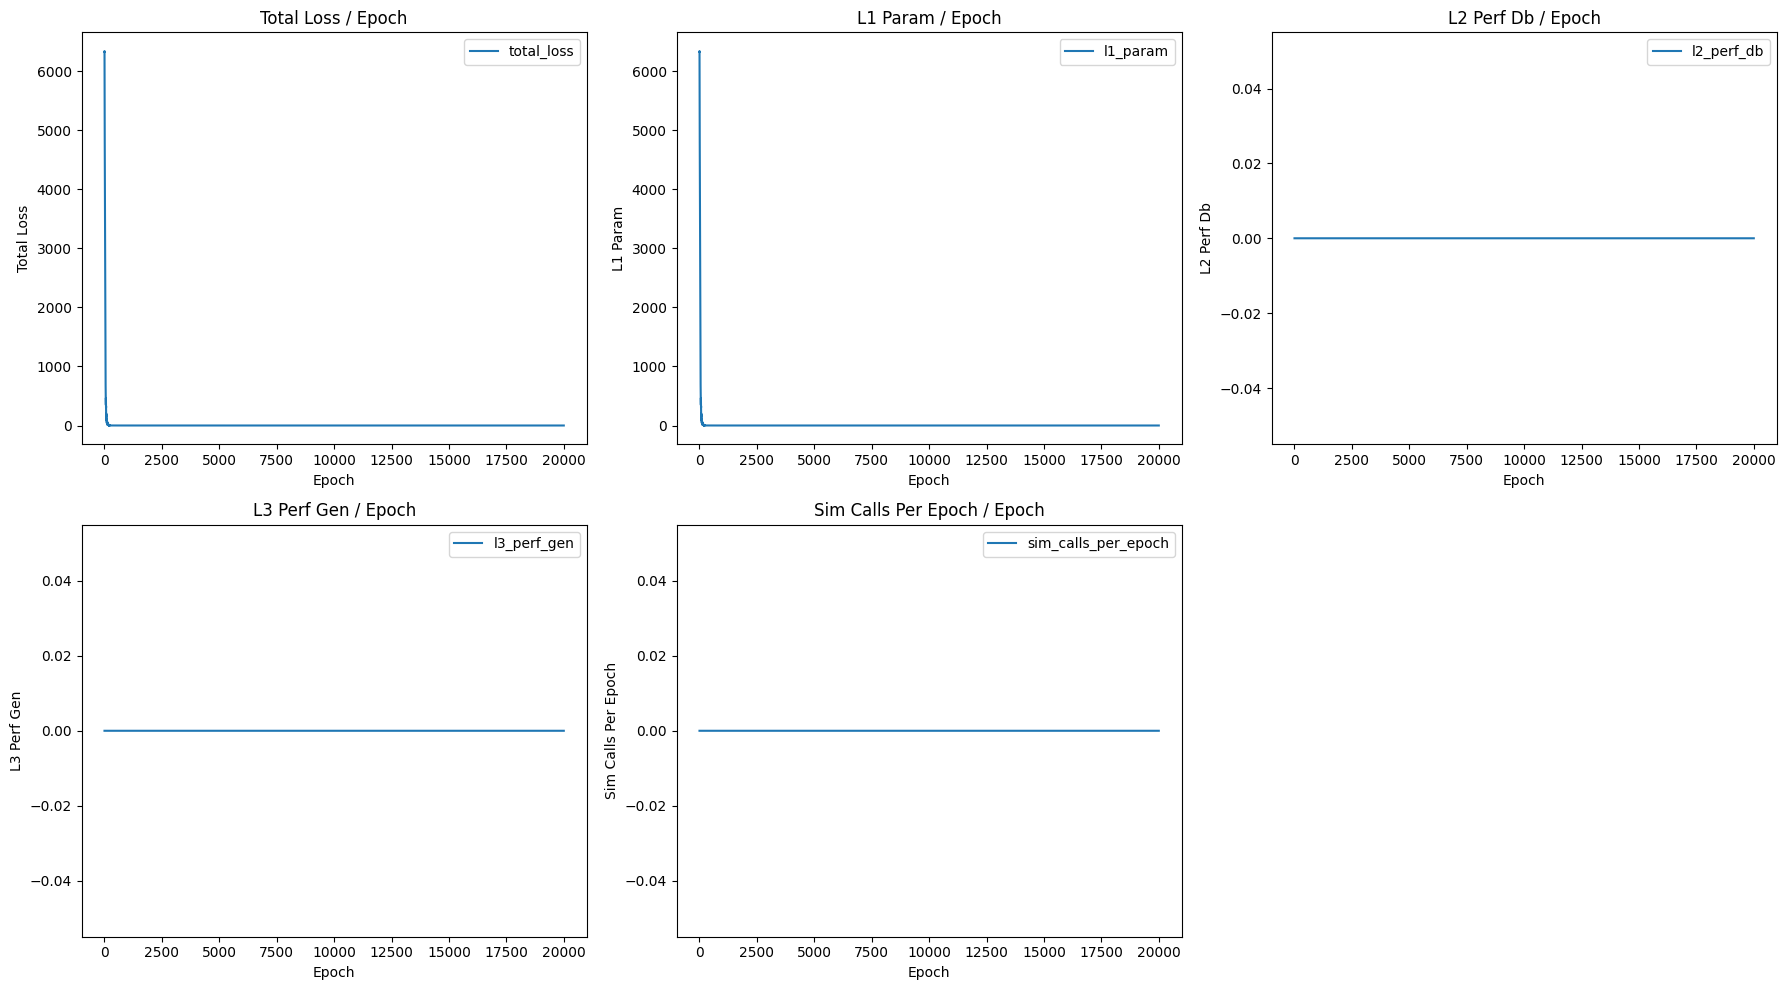

In [14]:
# Plot the training history
try:
    import matplotlib.pyplot as plt
    plt.figure(figsize=(18, 10))
    plot_keys = ['total_loss', 'l1_param', 'l2_perf_db', 'l3_perf_gen', 'sim_calls_per_epoch']
    for i, key in enumerate(plot_keys):
        if key in training_history_fd and training_history_fd[key]:
            plt.subplot(2, 3, i + 1)
            plt.plot(training_history_fd['epoch'], training_history_fd[key], label=key)
            plt.xlabel('Epoch')
            plt.ylabel(key.replace('_', ' ').title())
            plt.legend()
            plt.title(f'{key.replace("_", " ").title()} / Epoch')
    plt.tight_layout()
    plt.show()
except ImportError:
    print("Matplotlib not found. Skipping the history plot.")
except Exception as e:
    print(f"Plotting error: {e}")

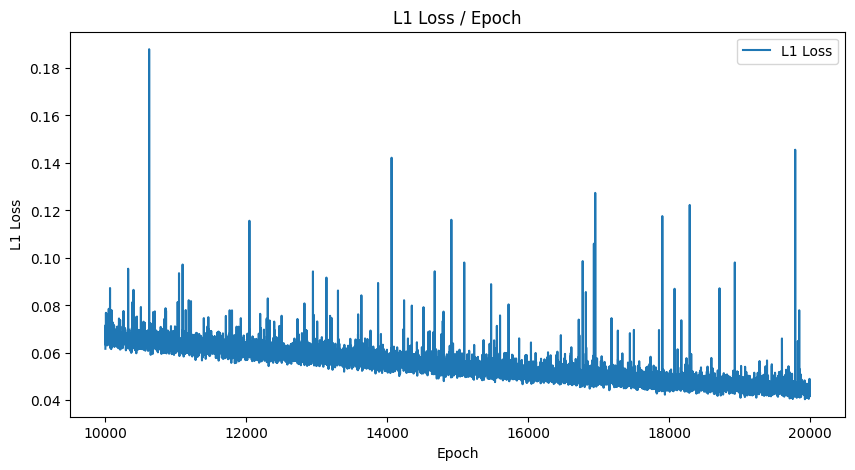

In [33]:
# Plot L1 loss separately over a selectable range
try:
    plt.figure(figsize=(10, 5))
    
    range_start = 10000
    range_end = NUM_EPOCHS
    epoch = training_history_fd['epoch'][range_start:range_end]
    loss = training_history_fd['l1_param'][range_start:range_end]
    
    plt.plot(epoch, loss, label='L1 Loss')
    plt.xlabel('Epoch')
    plt.ylabel('L1 Loss')
    plt.legend()
    plt.title('L1 Loss / Epoch')
    plt.show()
except:
    print("Whatever")

In [16]:
# # Load the model from the pathcircuit_database/SMC/P2C_model/P2C_Net_FD_SMC_20250522-153051.pt
# import torch
# p2c_model_fd = torch.load("circuit_database/SMC/P2C_model/P2C_Net_FD_SMC_20250522-153051.pt")

In [40]:
# Run an example prediction with the trained model
print("\nExample prediction after FD training:")
p2c_model_fd.eval() # Set evaluation mode
with torch.no_grad(): # Gradients are not needed for inference
    # Randomly select a database sample for testing
    sample_idx = np.random.randint(0, P_actual_db.shape[0])
    P_actual_db_tensor = torch.tensor(P_actual_db, dtype=torch.float32, device=device)
    C_actual_db_tensor = torch.tensor(C_actual_db, dtype=torch.float32, device=device)
    sample_p_actual = P_actual_db_tensor[sample_idx].unsqueeze(0).to(device)
    predicted_c_params = p2c_model_fd(sample_p_actual)
    print(f"Input performance (P_actual): \n{sample_p_actual.cpu().numpy()}")
    print(f"Predicted circuit parameters (C_pred): \n{predicted_c_params.cpu().numpy()}")
    
    print(f"Ground-truth circuit parameters (C_actual): \n{C_actual_db_tensor[sample_idx].cpu().numpy()}")

    print(f"Relative parameter error (C_pred vs C_actual): \n{(predicted_c_params - C_actual_db_tensor[sample_idx].unsqueeze(0).to(device)) / (C_actual_db_tensor[sample_idx].unsqueeze(0).to(device) + 1e-8)}")

    # Use the actual black-box simulator (not the FD wrapper) for validation
    simulated_p_perf = C2P_Sim(predicted_c_params.detach(), DIM_PERFS_K)
    print(f"Simulated performance for C_pred (P_simulated via black_box_S): \n{simulated_p_perf.cpu().numpy()}")
    
    simulated_p_perf = simulated_p_perf.to(device)
    
    print(f"Relative performance error (P_simulated vs P_actual): \n{(simulated_p_perf - sample_p_actual) / (sample_p_actual + 1e-8)}")


Example prediction after FD training:
Input performance (P_actual): 
[[3.88072e+07 8.75665e+01 5.79513e-03]]
Predicted circuit parameters (C_pred): 
[[8.8283716e-04 7.9896006e-07 3.5229509e-04 1.5492851e-06 2.9581828e-05
  1.6135584e-06 6.0647435e-04 5.2397195e-07 8.2122558e-04 1.9119959e-06
  2.0472565e-12]]
Ground-truth circuit parameters (C_actual): 
[8.8685268e-04 7.8562988e-07 3.4251442e-04 1.5547168e-06 2.5122863e-05
 1.6082106e-06 6.4299966e-04 5.2964225e-07 7.7354908e-04 1.8911628e-06
 2.1722188e-12]
Relative parameter error (C_pred vs C_actual): 
tensor([[-4.5278e-03,  1.6754e-02,  2.8555e-02, -3.4714e-03,  1.7742e-01,
          3.3048e-03, -5.6804e-02, -1.0508e-02,  6.1633e-02,  1.0958e-02,
         -1.2494e-05]], device='cuda:0')
Simulated performance for C_pred (P_simulated via black_box_S): 
[[4.79086e+07 8.75025e+01 5.71604e-03]]
Relative performance error (P_simulated vs P_actual): 
tensor([[ 0.2345, -0.0007, -0.0136]], device='cuda:0')


In [37]:
# Compute the maximum, minimum, and mean relative errors
Relative = (predicted_c_params - C_actual_db_tensor[sample_idx].unsqueeze(0).to(device)) / (C_actual_db_tensor[sample_idx].unsqueeze(0).to(device))
# Take the absolute value
Relative = torch.abs(Relative)

print(f"Maximum relative error: {torch.max(Relative)}")
print(f"Minimum relative error: {torch.min(Relative)}")
print(f"Mean relative error: {torch.mean(Relative)}")

Maximum relative error: 0.14320221543312073
Minimum relative error: 0.006817923858761787
Mean relative error: 0.040944915264844894


In [41]:
# Test with a custom sample


P_custom = np.array([[10e6, 100, 0.5e-3]]) # Custom performance metrics

P_custom_tensor = torch.tensor(P_custom, dtype=torch.float32, device=device)

starttime = time.time()
Predicted_C_custom = p2c_model_fd(P_custom_tensor)
end_time = time.time()
print(f"time: {end_time - starttime:.4f} s")

print(f"Custom performance metrics (P_custom): \n{P_custom}")
print(f"Predicted circuit parameters for custom performance (C_pred): \n{Predicted_C_custom.cpu().detach().numpy()}")
# Use the actual black-box simulator (not the FD wrapper) for validation

simulated_p_perf_custom = C2P_Sim(Predicted_C_custom, DIM_PERFS_K)
print(f"Simulated performance for C_pred (P_simulated via black_box_S): \n{simulated_p_perf_custom.cpu().numpy()}")

time: 0.0004 s
Custom performance metrics (P_custom): 
[[1.e+07 1.e+02 5.e-04]]
Predicted circuit parameters for custom performance (C_pred): 
[[1.2509312e-04 1.8082101e-06 1.0838972e-04 1.9008164e-06 5.3182375e-06
  9.1122843e-07 7.7561155e-04 5.7612687e-07 2.2421134e-05 1.4138940e-06
  2.3233076e-12]]
Simulated performance for C_pred (P_simulated via black_box_S): 
[[1.18597e+07 9.98778e+01 4.53210e-04]]


## Evaluation with Loss2 and Loss3

Loss2 and Loss3 mainly consume time during backpropagation. We can omit them from training and backpropagate only Loss1, while still computing Loss2 and Loss3 as monitoring metrics.

## Fine-Tuning

Training with Loss2 and Loss3 is too time-consuming.

Perform this fine-tuning here with fewer epochs and a smaller batch size.

# TuRBO Optimization

TuRBO is invoked through two command-line scripts under `scripts/` (each reads one specification line from stdin):
`run_sizing.py` is a cold start (no initial point), while `run_sizing_warmstart.py` accepts an initial point from P2C Net.

Bias-current conversion: 5e-4 / 1.8 = 2.78e-4


echo "SMC;10e6;60;100;2.78e-4" | python -u scripts/run_sizing.py > initial_no-1533.log

echo "SMC;10e6;60;100;2.78e-4;[1.2509312e-04 1.8082101e-06 1.0838972e-04 1.9008164e-06 5.3182375e-06 9.1122843e-07 7.7561155e-04 5.7612687e-07 2.2421134e-05 1.4138940e-06 2.3233076e-12]" | python -u scripts/run_sizing_warmstart.py > initial-1533.log

echo "[ckt_name];[GBW];[PM];[DC_gain];[Idd]" | python -u scripts/run_sizing.py > initial_no.log

In [30]:
Circuit_P = '8.67e-05 1.2e-06 9.86e-06 1.63e-06 1.53e-05 1.62e-06 0.000585 6.34e-07 0.000132 1.26e-06 2.87e-12'
# Convert to a NumPy array
Circuit_P = np.fromstring(Circuit_P, sep=' ')
Circuit_P = torch.tensor(Circuit_P, dtype=torch.float32, device=device).unsqueeze(0)
# Simulate
simulated_p_perf_custom = C2P_Sim(Circuit_P, DIM_PERFS_K)

print(f"Custom circuit parameters (C_custom): \n{Circuit_P.cpu().numpy()}")
print(f"Simulated performance for custom circuit parameters (P_simulated via black_box_S): \n{simulated_p_perf_custom.cpu().numpy()}")

Custom circuit parameters (C_custom): 
[[8.67e-05 1.20e-06 9.86e-06 1.63e-06 1.53e-05 1.62e-06 5.85e-04 6.34e-07
  1.32e-04 1.26e-06 2.87e-12]]
Simulated performance for custom circuit parameters (P_simulated via black_box_S): 
[[1.00581e+07 9.47519e+01 4.64532e-04]]


In [19]:
target_P = P_custom
initial_C = Predicted_C_custom

